<a href="https://colab.research.google.com/github/manan36chauhan/nlp_rag_ai_ml/blob/First-init/M507B_Methods_of_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Student Name : Manan Girishbhai Chauhan
### StudentId : GH1047553
### Subject name : Method Of Prediction



# Business Context
### Household Electricity Consumption
- Accurate forecasting of houshold power usage is crucial for energy providers and utility companies and smart grid operators to ensuere effecient energy distribution and price control.
- Predicting future power usage by processing consumption data, also organization can reduce the load risk.
- This project addresses a real business need by providing decision for energy pricing and management.


### Dataset : UCI Household power Consumption
- Link : https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip

In [ ]:
!wget -O /content/household_power_consumption.zip https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip

--2025-12-18 11:02:21--  https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/household_power_consumption.zip’

/content/household_     [  <=>               ]  19.68M  88.2MB/s    in 0.2s    

2025-12-18 11:02:21 (88.2 MB/s) - ‘/content/household_power_consumption.zip’ saved [20640916]



In above cell I have downloaded the dataset from the given link and stored in google collab folder. This dataset provides information about consumption of house electricity processing that we can predict the power consumption for next hour.

In [ ]:
!unzip /content/household_power_consumption.zip -d /content/

Archive:  /content/household_power_consumption.zip
replace /content/household_power_consumption.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/household_power_consumption.txt  


Above cell represent the dataset is in zipped in this cell I have unzipped dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import normaltest
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import time
import warnings
warnings.filterwarnings('ignore')


In Above step all necessary lib files and model imported to predict the power consumption.

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In above cell Visualizaton predefine configured

### 1 . Data Loading Explicit date and time format


In [ ]:
csv_path = "/content/household_power_consumption.txt"
df = pd.read_csv(csv_path, sep=';', na_values='?', low_memory=False)
df.rename(columns=lambda x: x.strip(), inplace=True)

df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format="%d/%m/%Y %H:%M:%S")
df.drop(columns=['Date', 'Time'], inplace=True)
df.set_index('dt', inplace=True)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f" Dataset displayed: {df.shape[0]:,} and samples, {df.shape[1]} and features")
print(f"  Period: {df.index.min()} --> {df.index.max()} ({(df.index.max()-df.index.min()).days} days)")
df.head()


 Dataset displayed: 2,075,259 and samples, 7 and features
  Period: 2006-12-16 17:24:00 --> 2010-11-26 21:02:00 (1441 days)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Cell start by collecting 4 years of electricity readings, measured every minute and that we will be converted into hourly datapoints.
This dataset has more than 2 million data points.


## 2. Data Quality Check

In [ ]:

target = 'Global_active_power'
print(f"Target variable: {target}")
print(f"\nMissing Value:-")
for col in df.columns:
    missing = df[col].isna().sum()
    pct = missing / len(df) * 100
    print(f"  {col}: {missing:,} ({pct:.2f}%)")


print(f"Mean: {df[target].mean():.3f} kW")
print(f"Std:  {df[target].std():.3f} kW")
print(f"Range: [{df[target].min():.3f}, {df[target].max():.3f}] kW")
zeros = (df[target] == 0).sum()

print(f"  Zero values: {zeros:,}")
Q1, Q3 = df[target].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = ((df[target] < Q1 - 1.5*IQR) | (df[target] > Q3 + 1.5*IQR)).sum()
print(f"  Outliers: {outliers:,}")



Target variable: Global_active_power

Missing Value:-
  Global_active_power: 25,979 (1.25%)
  Global_reactive_power: 25,979 (1.25%)
  Voltage: 25,979 (1.25%)
  Global_intensity: 25,979 (1.25%)
  Sub_metering_1: 25,979 (1.25%)
  Sub_metering_2: 25,979 (1.25%)
  Sub_metering_3: 25,979 (1.25%)
Mean: 1.092 kW
Std:  1.057 kW
Range: [0.076, 11.122] kW
  Zero values: 0
  Outliers: 94,907


 In above cell checking the quality of dataset like missing values, Strange spikes, zeros and Noise, Above cell has target value for instance here model will predict the Global active power,
 this is the total household electricity usage at a given time and Measured in kilowatts, Missing values out of the data in different features don't have measurements, for target like Mean std and range given. and we can see outliers of the data has high and low pattern.

## 3. Resampling to Hourly

In [ ]:
df_hour = df.resample('h').mean()
print(f"Resampled: {len(df):,} --> {len(df_hour):,} samples ({len(df_hour)/len(df)*100:.1f}%)")


Resampled: 2,075,259 --> 34,589 samples (1.7%)


Minute level data has high noise The original data has minutes samples so that it containes noise it will generate the fluctuations so that resampling into hourly is neccessary step to prevent this problem.

## 4. Time Series Split  - Before preprocessing to prevent leakage

In [ ]:
n = len(df_hour)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

df_train = df_hour.iloc[:train_end]
df_val = df_hour.iloc[train_end:val_end]
df_test = df_hour.iloc[val_end:]

print(f"Train  {len(df_train):>5,} sample | {df_train.index[0]} → {df_train.index[-1]}")
print(f"Val{len(df_val):>5,} sample | {df_val.index[0]} → {df_val.index[-1]}")
print(f"Test {len(df_test):>5,} sample | {df_test.index[0]} → {df_test.index[-1]}")

Train  24,212 sample | 2006-12-16 17:00:00 → 2009-09-20 12:00:00
Val5,188 sample | 2009-09-20 13:00:00 → 2010-04-24 16:00:00
Test 5,189 sample | 2010-04-24 17:00:00 → 2010-11-26 21:00:00


In Above step spliting the dataset into train test and validation. here chronological sequence or splitting first can help to prevent the data leakage and model fittings.

## 5. EXPLORATORY DATA ANALYSIS

Peak hour:- 21:00 (1.919 kW)
Low hour:  3:00 (0.442 kW)
Peak day:  Sat (1.259 kW)
Low day:   Thu (0.949 kW)


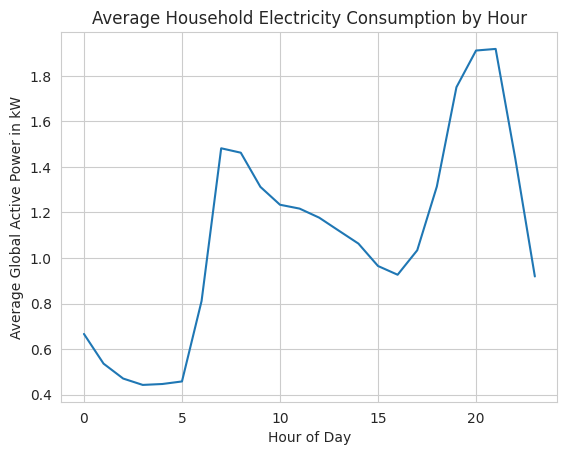

In [ ]:
df_tr_copy = df_train.copy()
df_tr_copy['hour'] = df_tr_copy.index.hour
df_tr_copy['dow'] = df_tr_copy.index.dayofweek

hourly_avg = df_tr_copy.groupby('hour')[target].mean()
daily_avg = df_tr_copy.groupby('dow')[target].mean()

print(f"Peak hour:- {hourly_avg.idxmax()}:00 ({hourly_avg.max():.3f} kW)")
print(f"Low hour:  {hourly_avg.idxmin()}:00 ({hourly_avg.min():.3f} kW)")
print(f"Peak day:  {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][daily_avg.idxmax()]} ({daily_avg.max():.3f} kW)")
print(f"Low day:   {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][daily_avg.idxmin()]} ({daily_avg.min():.3f} kW)")

df_tr_copy = df_train.copy()
df_tr_copy['hour'] = df_tr_copy.index.hour

hourly_avg = df_tr_copy.groupby('hour')[target].mean()

plt.figure()
plt.plot(hourly_avg.index, hourly_avg.values)
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power in kW")
plt.title("Average Household Electricity Consumption by Hour")
plt.show()

## 6. MISSING VALUE HANDLING (Independent for each split)

In [ ]:
df_train = df_train.interpolate(method='time').ffill().bfill()
df_val = df_val.interpolate(method='time').ffill().bfill()
df_test = df_test.interpolate(method='time').ffill().bfill()

print(f"missing in train:- {df_train.isna().sum().sum()}")
print(f"missing in val:-  {df_val.isna().sum().sum()}")
print(f"missing in test:-  {df_test.isna().sum().sum()}")

missing in train:- 0
missing in val:-  0
missing in test:-  0


Above cell describe the missing value fillers like forward fills and backard fills to enhance the quality of data and here interpolation used to fill the missing values.

## 7. STATIONARITY TEST

In [ ]:
adf_result = adfuller(df_train[target].dropna(), autolag='AIC')
print(f"Augmented Test:")
print(f"Statistic: {adf_result[0]:.4f}")
print(f"p-value:   {adf_result[1]:.4f}")

Augmented Test:
Statistic: -11.2133
p-value:   0.0000


In above cell low p value confirms the time series is stationary and it is suitable for time series modeling without additional differencing.

## 8.  Scaling data only to prevent the leakage

In [ ]:
data_tr = df_train[[target]].copy()
data_val = df_val[[target]].copy()
data_te = df_test[[target]].copy()

scaler = MinMaxScaler()
data_tr_sc = pd.DataFrame(scaler.fit_transform(data_tr),index=data_tr.index, columns=data_tr.columns)
data_val_sc = pd.DataFrame(scaler.transform(data_val),index=data_val.index, columns=data_val.columns)
data_te_sc = pd.DataFrame(scaler.transform(data_te),index=data_te.index, columns=data_te.columns)

print(f" Range of Train : [{data_tr_sc.min().values[0]:.3f}, {data_tr_sc.max().values[0]:.3f}]")
print(f" Range of Val :   [{data_val_sc.min().values[0]:.3f}, {data_val_sc.max().values[0]:.3f}]")
print(f"  Range of Test :  [{data_te_sc.min().values[0]:.3f}, {data_te_sc.max().values[0]:.3f}]")

 Range of Train : [0.000, 1.000]
 Range of Val :   [0.011, 0.810]
  Range of Test :  [0.011, 0.855]


In Scaling cell, it helps to prevents feature with larger magnitude from dominating the learning process and here Minmaxscaler has fitted on data.

## 9. Sliding Window Sequence creation

In [ ]:
def create_sequences(data, window, horizon=1):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window+horizon-1][0])
    return np.array(X), np.array(y)

WINDOW, HORIZON = 24, 1
X_tr, y_tr = create_sequences(data_tr_sc.values, WINDOW, HORIZON)
X_val, y_val = create_sequences(data_val_sc.values, WINDOW, HORIZON)
X_te, y_te = create_sequences(data_te_sc.values, WINDOW, HORIZON)

print(f"Config: window={WINDOW}h, horizon={HORIZON}h")
print(f"X_train: {X_tr.shape} | y_train: {y_tr.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"X_test:  {X_te.shape} | y_test:  {y_te.shape}")

Config: window=24h, horizon=1h
X_train: (24188, 24, 1) | y_train: (24188,)
X_val:   (5164, 24, 1) | y_val:   (5164,)
X_test:  (5165, 24, 1) | y_test:  (5165,)


This seuence or sliding generation has been used because the past hourly values are grouped into sequence and used to predict the next hours power consumptions. this will help the model to learn the daily cyles and weekly routine and long term usage insights.

## 10 Model Building

In [ ]:
def build_lstm(win, units=[64], dropout=0.2, lr=0.001, activation='tanh'):
    model = keras.Sequential([layers.Input(shape=(win, 1))])
    for i, u in enumerate(units):
        model.add(layers.LSTM(u, return_sequences=(i < len(units)-1), activation=activation))
        if dropout > 0: model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError(name='rmse'),
                          keras.metrics.MeanAbsoluteError(name='mae')])
    return model

def build_gru(win, units=[64], dropout=0.2, lr=0.001):
    model = keras.Sequential([layers.Input(shape=(win, 1))])
    for i, u in enumerate(units):
        model.add(layers.GRU(u, return_sequences=(i < len(units)-1)))
        if dropout > 0: model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

def build_cnn_lstm(win, filters=64, kernel=3, lstm_units=64, dropout=0.2, lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(win, 1)),
        layers.Conv1D(filters, kernel, activation='relu', padding='same'),
        layers.MaxPooling1D(2),
        layers.LSTM(lstm_units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

In above step I have used different models to check which is best like GRU, LSTM and CNN with LSTM used. those models are used for time series problem. Tried different configurations like units, dropout, optimizers.

## 11 HYPERPARAMETER EXPERIMENTS

In [ ]:
experiments = [
    {"name": "LSTM_baseline_64", "type": "lstm", "units": [64], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_shallow_32", "type": "lstm", "units": [32], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_deep_64_32", "type": "lstm", "units": [64,32], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_wide_128", "type": "lstm", "units": [128], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_deep_128_64", "type": "lstm", "units": [128,64], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_no_dropout", "type": "lstm", "units": [64,32], "dropout": 0.0, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_high_dropout", "type": "lstm", "units": [64,32], "dropout": 0.4, "lr": 0.001, "act": "tanh", "win": 24},
    {"name": "LSTM_low_lr", "type": "lstm", "units": [64,32], "dropout": 0.2, "lr": 5e-4, "act": "tanh", "win": 24},
    {"name": "LSTM_relu", "type": "lstm", "units": [64,32], "dropout": 0.2, "lr": 0.001, "act": "relu", "win": 24},
    {"name": "LSTM_window48", "type": "lstm", "units": [64,32], "dropout": 0.2, "lr": 0.001, "act": "tanh", "win": 48},
    {"name": "GRU_baseline", "type": "gru", "units": [64], "dropout": 0.2, "lr": 0.001, "win": 24},
    {"name": "CNN_LSTM_hybrid", "type": "cnn", "filters": 64, "kernel": 3, "lstm": 64, "dropout": 0.2, "lr": 0.001, "win": 24}
]

def get_data(win):
    if win == WINDOW:
        return X_tr, X_val, X_te, y_tr, y_val, y_te
    Xtr, ytr = create_sequences(data_tr_sc.values, win, HORIZON)
    Xv, yv = create_sequences(data_val_sc.values, win, HORIZON)
    Xte, yte = create_sequences(data_te_sc.values, win, HORIZON)
    return Xtr, Xv, Xte, ytr, yv, yte

results = []
print(f"Running {len(experiments)} experiment....\n")

for i, cfg in enumerate(experiments, 1):
    print(f"[{i:2d}/{len(experiments)}] {cfg['name']:<25}", end=" ")

    win = cfg.get('win', WINDOW)
    Xtr, Xv, Xt, ytr, yv, yt = get_data(win)

    t0 = time.time()
    if cfg['type'] == 'lstm':
        model = build_lstm(win, cfg['units'], cfg['dropout'], cfg['lr'], cfg['act'])
    elif cfg['type'] == 'gru':
        model = build_gru(win, cfg['units'], cfg['dropout'], cfg['lr'])
    else:
        model = build_cnn_lstm(win, cfg['filters'], cfg['kernel'], cfg['lstm'], cfg['dropout'], cfg['lr'])

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xv, yv), epochs=20, batch_size=64,
                     callbacks=[early_stop], verbose=0)

    val_rmse = min(hist.history['val_rmse'])
    train_time = time.time() - t0

    results.append({'name': cfg['name'], 'val_rmse': val_rmse, 'time': train_time,
                   'epochs': len(hist.history['loss']), 'config': cfg})

    print(f"RMSE: {val_rmse:.5f} | {train_time:.1f}s | {len(hist.history['loss'])} epochs")

res_df = pd.DataFrame(results).sort_values('val_rmse').reset_index(drop=True)

print("EXPERIMENT RESULTS sorted by validation RMSE")

print(res_df[['name', 'val_rmse', 'time', 'epochs']].to_string(index=False))

Running 12 experiment....

[ 1/12] LSTM_baseline_64          RMSE: 0.09004 | 53.9s | 20 epochs
[ 2/12] LSTM_shallow_32           RMSE: 0.09067 | 46.2s | 20 epochs
[ 3/12] LSTM_deep_64_32           RMSE: 0.08998 | 66.0s | 20 epochs
[ 4/12] LSTM_wide_128             RMSE: 0.09020 | 48.8s | 20 epochs
[ 5/12] LSTM_deep_128_64          RMSE: 0.09002 | 69.3s | 20 epochs
[ 6/12] LSTM_no_dropout           RMSE: 0.08955 | 57.5s | 20 epochs
[ 7/12] LSTM_high_dropout         RMSE: 0.09017 | 73.2s | 20 epochs
[ 8/12] LSTM_low_lr               RMSE: 0.09021 | 69.8s | 20 epochs
[ 9/12] LSTM_relu                 RMSE: 0.08967 | 59.0s | 20 epochs
[10/12] LSTM_window48             RMSE: 0.08813 | 74.0s | 20 epochs
[11/12] GRU_baseline              RMSE: 0.09003 | 44.8s | 20 epochs
[12/12] CNN_LSTM_hybrid           RMSE: 0.08914 | 54.6s | 20 epochs
EXPERIMENT RESULTS sorted by validation RMSE
             name  val_rmse      time  epochs
    LSTM_window48  0.088128 73.986301      20
  CNN_LSTM_hybrid  0

In [ ]:
import pandas as pd

formatted_results = []

for idx, row in enumerate(results, 1):
    cfg = row['config']

    model_type = cfg['type'].upper()

    if cfg['type'] in ['lstm', 'gru']:
        num_layers = len(cfg['units'])
        units = ','.join(map(str, cfg['units']))
    else:
        num_layers = 2
        units = f"CNN:{cfg['filters']},LSTM:{cfg['lstm']}"


    dropout = cfg.get('dropout', 0.0)
    lr = cfg.get('lr', 0.001)
    window = cfg.get('win', 24)
    val_rmse = row['val_rmse']

    formatted_results.append({
        'Experiment': f'E{idx}',
        'Model Type': model_type,
        'Layers': num_layers,
        'Units': units,
        'Dropout': dropout,
        'Learning Rate': lr,
        'Window Size': window,
        'Val RMSE': round(val_rmse, 6)
    })


df_formatted = pd.DataFrame(formatted_results).sort_values('Val RMSE').reset_index(drop=True)

df_formatted['Experiment'] = [f'E{i+1}' for i in range(len(df_formatted))]
print("EXPERIMENT RESULTS (Sorted by Validation RMSE)")
print(df_formatted.to_string(index=False))


EXPERIMENT RESULTS (Sorted by Validation RMSE)
Experiment Model Type  Layers          Units  Dropout  Learning Rate  Window Size  Val RMSE
        E1       LSTM       2          64,32      0.2         0.0010           48  0.088128
        E2        CNN       2 CNN:64,LSTM:64      0.2         0.0010           24  0.089136
        E3       LSTM       2          64,32      0.0         0.0010           24  0.089551
        E4       LSTM       2          64,32      0.2         0.0010           24  0.089672
        E5       LSTM       2          64,32      0.2         0.0010           24  0.089981
        E6       LSTM       2         128,64      0.2         0.0010           24  0.090018
        E7        GRU       1             64      0.2         0.0010           24  0.090033
        E8       LSTM       1             64      0.2         0.0010           24  0.090038
        E9       LSTM       2          64,32      0.4         0.0010           24  0.090171
       E10       LSTM       1    

increasing the number of layers and two models diminshing returns and overliffting by increased validation error.
Larger hiiden units improves unstable training while very low learning rates. used dropout to reduce the overfitting but it degraded the performance by limiting learnning capacity.

## 12 Final model training test evaluation

In [ ]:
best = res_df.iloc[0]
best_cfg = best['config']
print(f"\nBest Model: {best['name']}")
print(f"Config: {best_cfg}")
print(f"Val RMSE (scaled): {best['val_rmse']:.5f}\n")

win = best_cfg.get('win', WINDOW)
Xtr, Xv, Xt, ytr, yv, yt = get_data(win)
X_full = np.concatenate([Xtr, Xv])
y_full = np.concatenate([ytr, yv])

win = best_cfg.get('win', WINDOW)
Xtr, Xv, Xt, ytr, yv, yt = get_data(win)
X_full = np.concatenate([Xtr, Xv])
y_full = np.concatenate([ytr, yv])




Best Model: LSTM_window48
Config: {'name': 'LSTM_window48', 'type': 'lstm', 'units': [64, 32], 'dropout': 0.2, 'lr': 0.001, 'act': 'tanh', 'win': 48}
Val RMSE (scaled): 0.08813



Test Set Performance:
  RMSE: 0.487 kW
  MAE:  0.347 kW
  MAPE: 50.68 %
  R2:   0.519
PHASE 14: PREDICTION VISUALIZATION & ERROR ANALYSIS


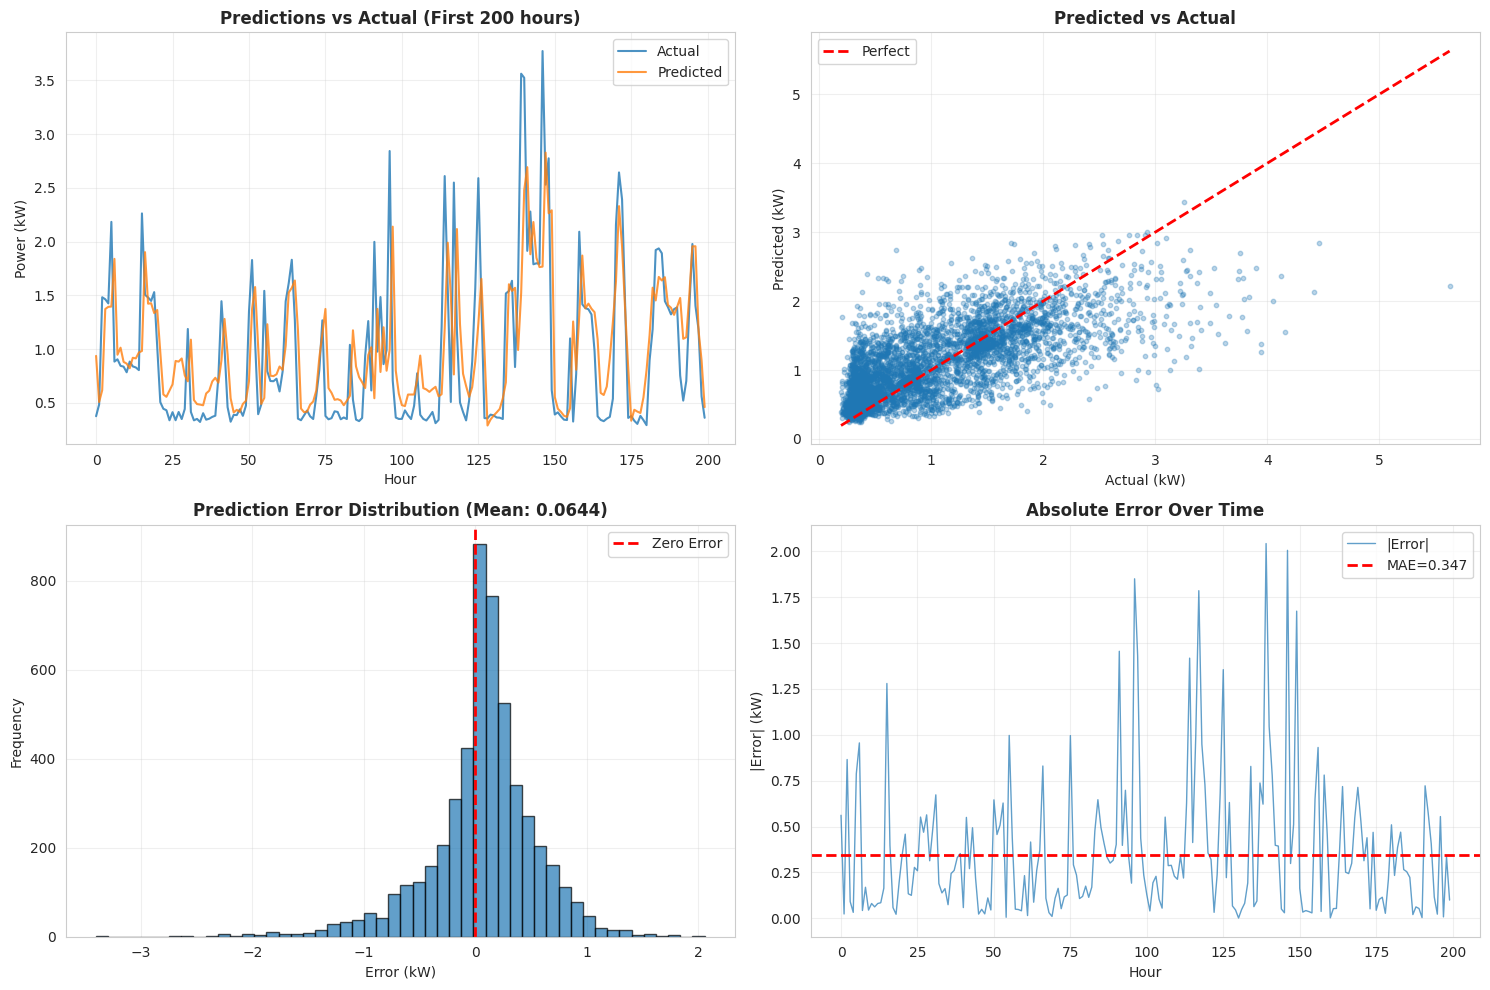

In [ ]:
best_cfg = res_df.iloc[0]['config']

win = best_cfg.get('win', WINDOW)
Xtr, Xv, Xt, ytr, yv, yt = get_data(win)
X_full = np.concatenate([Xtr, Xv])
y_full = np.concatenate([ytr, yv])


if best_cfg['type'] == 'lstm':
    model = build_lstm(win, best_cfg['units'], best_cfg['dropout'], best_cfg['lr'], best_cfg['act'])
elif best_cfg['type'] == 'gru':
    model = build_gru(win, best_cfg['units'], best_cfg['dropout'], best_cfg['lr'])
else:
    model = build_cnn_lstm(win, best_cfg['filters'], best_cfg['kernel'], best_cfg['lstm'], best_cfg['dropout'], best_cfg['lr'])


model.fit(X_full, y_full, epochs=best['epochs'], batch_size=64, verbose=0)


predictions_scaled = model.predict(Xt, verbose=0).flatten()


true_scaled = yt.flatten()

true = scaler.inverse_transform(true_scaled.reshape(-1,1)).flatten()
pred = scaler.inverse_transform(predictions_scaled.reshape(-1,1)).flatten()


rmse = np.sqrt(mean_squared_error(true, pred))
mae = mean_absolute_error(true, pred)
mape = mean_absolute_percentage_error(true, pred) * 100
r2 = r2_score(true, pred)

print(f"Test Set Performance:")
print(f"  RMSE: {rmse:.3f} kW")
print(f"  MAE:  {mae:.3f} kW")
print(f"  MAPE: {mape:.2f} %")
print(f"  R2:   {r2:.3f}")


print("PHASE 14: PREDICTION VISUALIZATION & ERROR ANALYSIS")


fig, axes = plt.subplots(2, 2, figsize=(15, 10))


ax = axes[0, 0]
ax.plot(true[:200], label='Actual', linewidth=1.5, alpha=0.8)
ax.plot(pred[:200], label='Predicted', linewidth=1.5, alpha=0.8)
ax.set_title('Predictions vs Actual (First 200 hours)', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Power (kW)'); ax.legend(); ax.grid(alpha=0.3)


ax = axes[0, 1]
ax.scatter(true, pred, alpha=0.3, s=10)
ax.plot([true.min(), true.max()], [true.min(), true.max()], 'r--', lw=2, label='Perfect')
ax.set_title('Predicted vs Actual', fontweight='bold')
ax.set_xlabel('Actual (kW)'); ax.set_ylabel('Predicted (kW)'); ax.legend(); ax.grid(alpha=0.3)


ax = axes[1, 0]
errors = pred - true
ax.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_title(f'Prediction Error Distribution (Mean: {errors.mean():.4f})', fontweight='bold')
ax.set_xlabel('Error (kW)'); ax.set_ylabel('Frequency'); ax.legend(); ax.grid(alpha=0.3)


ax = axes[1, 1]
ax.plot(np.abs(errors[:200]), label='|Error|', linewidth=1, alpha=0.7)
ax.axhline(mae, color='r', linestyle='--', linewidth=2, label=f'MAE={mae:.3f}')
ax.set_title('Absolute Error Over Time', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('|Error| (kW)'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()

## Final discussion

**Strengths**
    - This forcasting pipeline effectively models dependecnies in houshold power consumption data
    - LSTM architecturesn are well suied for seuqential data and retrieved sztong validation and test performance.
    - The chronological dataspliting and hyperparameter experiemntations ensure the realistic evaluation.



**Limitation**
    - The model requires higher computatioal resources compared to simpler approche and it offers limited interpretebaility. Moreover only historical usage data is used while external factors are not considered.

**Business Implication**
    - Accurate short term electicity forcasts support improve load plan and cost reduction technique for efficient energy.

**Recommendation**
    - The moddel computationaly feasible for deployment and training it can be integrated into a rolling prediction system with additional features and methods.